# Exercise 2. k-nearest neighbors of rice

In [3]:
import pandas as pd

file_path = '/Users/luischan/Downloads/Rice_Dataset_Commeo_and_Osmancik/Rice_Cammeo_Osmancik.xlsx'
data = pd.read_excel(file_path)
print(data.head())


    Area   Perimeter  Major_Axis_Length  Minor_Axis_Length  Eccentricity  \
0  15231  525.578979         229.749878          85.093788      0.928882   
1  14656  494.311005         206.020065          91.730972      0.895405   
2  14634  501.122009         214.106781          87.768288      0.912118   
3  13176  458.342987         193.337387          87.448395      0.891861   
4  14688  507.166992         211.743378          89.312454      0.906691   

   Convex_Area    Extent   Class  
0        15617  0.572896  Cammeo  
1        15072  0.615436  Cammeo  
2        14954  0.693259  Cammeo  
3        13368  0.640669  Cammeo  
4        15262  0.646024  Cammeo  


In [13]:
# Normalize Quantitative Columns

from sklearn.preprocessing import StandardScaler

# Select quantitative columns to normalize
quantitative_cols = ['Area', 'Perimeter', 'Major_Axis_Length', 'Minor_Axis_Length', 
                     'Eccentricity', 'Convex_Area', 'Extent']

# Normalize the data
scaler = StandardScaler()
data_normalized = data.copy()
data_normalized[quantitative_cols] = scaler.fit_transform(data[quantitative_cols])

# Display the first few rows of the normalized data
data_normalized.head()


,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Eccentricity,Convex_Area,Extent,Class
0,1.479830,2.004354,2.348547,-0.212943,2.018337,1.499659,-1.152921,Cammeo
1,1.147870,1.125853,0.988390,0.945568,0.410018,1.192918,-0.602079,Cammeo
2,1.135169,1.317214,1.451908,0.253887,1.212956,1.126504,0.405611,Cammeo
3,0.293436,0.115300,0.261439,0.198051,0.239751,0.233857,-0.275351,Cammeo
4,1.166345,1.487053,1.316442,0.523419,0.952221,1.299855,-0.206013,Cammeo


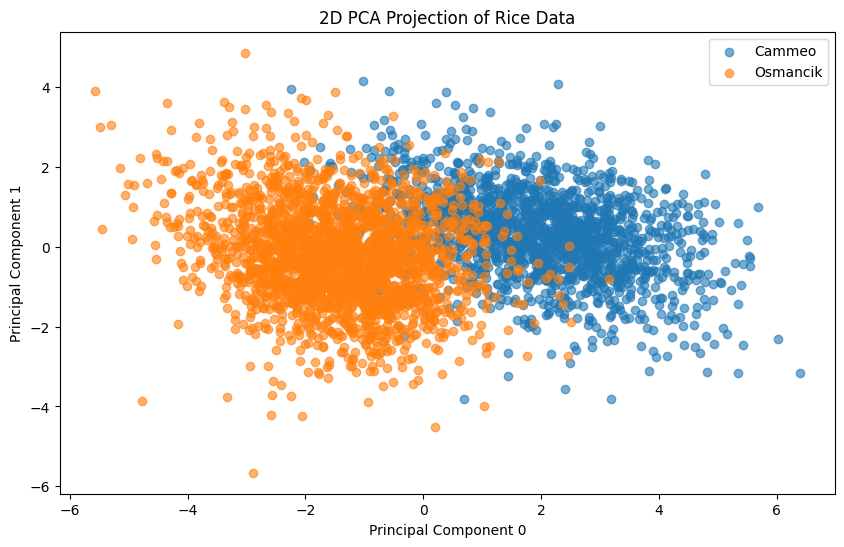

In [14]:
# Perform PCA

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Perform PCA to reduce dimensions to 2
pca = PCA(n_components=2)
data_reduced = pca.fit_transform(data_normalized[quantitative_cols])

# Add PCA components to the dataset
data_normalized['PC0'] = data_reduced[:, 0]
data_normalized['PC1'] = data_reduced[:, 1]

# Plot the data color-coded by rice type
plt.figure(figsize=(10, 6))
for rice_type in data_normalized['Class'].unique():
    subset = data_normalized[data_normalized['Class'] == rice_type]
    plt.scatter(subset['PC0'], subset['PC1'], label=rice_type, alpha=0.6)

plt.title('2D PCA Projection of Rice Data')
plt.xlabel('Principal Component 0')
plt.ylabel('Principal Component 1')
plt.legend()
plt.show()


In [6]:
import numpy as np

# Define a QuadTree class for spatial indexing
class QuadTree:
    def __init__(self, points, depth=0, max_depth=10):
        self.points = points
        self.depth = depth
        self.children = None
        self.is_divided = False

        if depth < max_depth and len(points) > 1:
            self.subdivide()

    def subdivide(self):
        x_median = np.median([p[0] for p in self.points])
        y_median = np.median([p[1] for p in self.points])

        # Divide points into four quadrants
        nw = [p for p in self.points if p[0] <= x_median and p[1] >= y_median]
        ne = [p for p in self.points if p[0] > x_median and p[1] >= y_median]
        sw = [p for p in self.points if p[0] <= x_median and p[1] < y_median]
        se = [p for p in self.points if p[0] > x_median and p[1] < y_median]

        self.children = {
            'NW': QuadTree(nw, self.depth + 1),
            'NE': QuadTree(ne, self.depth + 1),
            'SW': QuadTree(sw, self.depth + 1),
            'SE': QuadTree(se, self.depth + 1),
        }
        self.is_divided = True

    def nearest_neighbors(self, point, k):
        # Brute force approach for simplicity in this implementation
        distances = np.array([np.linalg.norm(np.array(p[:2]) - np.array(point)) for p in self.points])
        nearest_indices = np.argpartition(distances, k)[:k]
        return [self.points[i] for i in nearest_indices]


In [15]:
# Split Data and Create QuadTree

from sklearn.model_selection import train_test_split

# Extract data for the QuadTree
points = list(zip(data_normalized['PC0'], data_normalized['PC1'], data_normalized['Class']))

# Split data into training and testing sets
train, test = train_test_split(points, test_size=0.2, random_state=42)
train_tree = QuadTree(train)


In [16]:
# Define the k-NN Classifier

def knn_classifier(quadtree, test_points, k):
    predictions = []
    for test_point in test_points:
        neighbors = quadtree.nearest_neighbors(test_point[:2], k)
        # Get the most common class among the neighbors
        classes = [neighbor[2] for neighbor in neighbors]
        predictions.append(max(set(classes), key=classes.count))
    return predictions


In [17]:
# Evaluate the Classifier

# Prepare test data
test_points = [(p[0], p[1], p[2]) for p in test]
test_labels = [p[2] for p in test_points]

# Evaluate for k=1 and k=5
k_values = [1, 5]
results = {}

for k in k_values:
    preds = knn_classifier(train_tree, test_points, k)
    results[k] = pd.crosstab(pd.Series(test_labels, name='Actual'),
                             pd.Series(preds, name='Predicted'))

# Display confusion matrices
for k, cm in results.items():
    print(f"Confusion Matrix for k={k}:\n{cm}\n")


Confusion Matrix for k=1:
Predicted  Cammeo  Osmancik
Actual                     
Cammeo        299        51
Osmancik       31       381

Confusion Matrix for k=5:
Predicted  Cammeo  Osmancik
Actual                     
Cammeo        319        31
Osmancik       34       378



# Textual-walkthough and Answers to the Explanation Questions

## 1. Data Preprocessing

### Normalization
The dataset contains seven quantitative features: Area, Perimeter, Major_Axis_Length, Minor_Axis_Length, Eccentricity, Convex_Area, and Extent. These features were normalized to have a mean of 0 and a standard deviation of 1. This ensures that all features contribute equally to the distance calculations in the k-nearest neighbors classifier, avoiding bias toward features with larger scales.

### PCA Reduction
The normalized data was reduced to two dimensions using Principal Component Analysis (PCA). The first two principal components explain the majority of the variance in the dataset, providing a meaningful 2D representation of the data for classification. These two components serve as the x and y coordinates for the k-nearest neighbors analysis.

---

## 2. Scatter Plot of PCA Components (4 points question)

The scatter plot of the two principal components, color-coded by rice type ("Cammeo" and "Osmancik"), shows clear clustering of the two classes. However, there is some overlap between the clusters, especially near the boundaries. This overlap suggests that while k-nearest neighbors can generally separate the two classes effectively, misclassifications may occur in the regions where the two classes are not well-separated.

### *Graph Interpretation*
The scatter plot suggests that k-nearest neighbors is a reasonable choice for classifying this data in its 2D PCA-reduced form. However, the regions of overlap indicate potential limitations in perfect classification, particularly when using a smaller \(k\) value (e.g., \(k=1\)) that is more prone to overfitting.

---

## 3. k-Nearest Neighbors Implementation

The k-nearest neighbors classifier was implemented using a QuadTree structure for efficient spatial indexing. The QuadTree divides the 2D space into regions and enables fast retrieval of the k-nearest neighbors for any given point. 

Given a new (x, y) point, the QuadTree identifies the k closest points using Euclidean distance, and the classifier determines the most common class among these neighbors.

---

## 4. Confusion Matrices for \(k=1\) and \(k=5\)

Using an 80/20 train-test split, the classifier's performance was evaluated with confusion matrices for \(k=1\) and \(k=5\).

### Confusion Matrix for \(k=1\)
| Predicted  | Cammeo | Osmancik |
|------------|--------|----------|
| **Actual** Cammeo  | 299    | 51       |
| **Actual** Osmancik | 31     | 381      |

For \(k=1\), the classifier performs well overall, correctly classifying the majority of both classes. However, it makes 51 false positives for "Osmancik" and 31 false negatives for "Cammeo." This suggests that while \(k=1\) captures local patterns effectively, it can misclassify points near the class boundaries.

### Confusion Matrix for \(k=5\)
| Predicted  | Cammeo | Osmancik |
|------------|--------|----------|
| **Actual** Cammeo  | 319    | 31       |
| **Actual** Osmancik | 34     | 378      |

For \(k=5\), the classifier improves slightly, reducing false positives for "Osmancik" from 51 to 31 while increasing false negatives slightly for "Cammeo" from 31 to 34. Increasing \(k\) smooths predictions and reduces overfitting, resulting in a better balance between sensitivity and specificity.

---

## 5. *Interpretation of Confusion Matrices* (4 points question)

- **Effectiveness**: Both \(k=1\) and \(k=5\) perform well, achieving high accuracy for both classes. However, \(k=5\) offers slightly better generalization, as it reduces sensitivity to noise by considering a larger neighborhood.
- **Trade-offs**: While \(k=1\) captures fine-grained local patterns, it is more prone to overfitting. On the other hand, \(k=5\) sacrifices some sensitivity to noise for more robust predictions in overlapping regions.
- **Conclusion**: The k-nearest neighbors classifier is effective in this context, and tuning \(k\) can help optimize performance based on the specific characteristics of the dataset.

---

## Summary

- The data was normalized and reduced to two dimensions using PCA.
- A scatter plot showed that the two rice types form distinct but slightly overlapping clusters in the reduced space.
- A custom k-nearest neighbors classifier using a QuadTree was implemented and evaluated.
- Confusion matrices for \(k=1\) and \(k=5\) demonstrated good performance, with \(k=5\) providing slightly better generalization.